# Risco de Readmissão Longitudinal sob um Programa de Gestão de Cuidados com PROC GEE


## Resumo Executivo

Este notebook ajusta um modelo logístico marginal (com média populacional) para um desfecho binário de **readmissão em 30 dias**, medido repetidamente ao longo de quatro consultas de acompanhamento por paciente, usando o **PROC GEE** para considerar a correlação dentro do mesmo paciente. Numa coorte sintética balanceada de **25 pacientes acompanhados em 4 consultas cada (100 registros paciente-consulta)**, o modelo estima o efeito com média populacional de um **programa de Gestão de Cuidados** (`CareMgmt`) versus o cuidado padrão (`Standard`), ajustando por sexo, idade, carga de comorbidades e consulta.

O ajuste com correlação de trabalho permutável (exchangeable) retorna um coeficiente `factor(program)Standard` de **+2.306** na escala logit, com erro padrão empírico (sandwich) de **0.467** (Z = 4.94, p < 0.0001): os pacientes em cuidado padrão apresentam chances de readmissão marcadamente mais altas do que os pacientes em Gestão de Cuidados. Exponenciando o contraste obtém-se uma **razão de chances (odds ratio) de Gestão de Cuidados versus Padrão de 0.10 (IC de Wald de 95% de 0.040 a 0.249)** — um efeito protetor forte e estatisticamente significativo, cujo intervalo de confiança exclui 1. Uma correlação de trabalho AR(1) reproduz praticamente o mesmo coeficiente (**+2.315**), e a estrutura permutável se ajusta melhor pelo QIC (**111.77** vs **123.94**), portanto a conclusão não é um artefato da correlação assumida.

## Fontes de Dados

Todos os dados são gerados internamente pela primeira etapa DATA (sem arquivos externos, semente fixa `101`). Uma coorte sintética, `readmit`, contém **25 pacientes, cada um observado em 4 consultas (100 linhas paciente-consulta)** — um desenho longitudinal balanceado, dimensionado para o limite de 100 observações deste ambiente, com `patient` como unidade de agrupamento (clustering).

| Variável | Tipo | Descrição |
|----------|------|-------------|
| `patient` | num | ID do paciente — a unidade de agrupamento/sujeito para as medidas repetidas |
| `visit` | num | Número da consulta de acompanhamento (1-4), o índice de tempo intra-sujeito |
| `program` | char | Programa de cuidado: `CareMgmt` (intervenção) ou `Standard` |
| `sex` | char | Sexo do paciente (`Female`/`Male`) |
| `age` | num | Idade em anos (~50-70) |
| `age_c` | num | Idade centralizada/escalonada, `(age-60)/10`, a covariável do modelo |
| `comorbid` | num | Contagem de comorbidades (Poisson, média ~2) |
| `readmit` | num | Desfecho binário: 1 = readmitido em até 30 dias da consulta, senão 0 |

O modelo gerador dos dados embute um verdadeiro efeito protetor do programa (log-odds de **-1.4** para `CareMgmt`), risco crescente com comorbidade e idade, uma leve tendência decrescente ao longo das consultas, e um intercepto aleatório a nível de paciente (`u`, DP 1.1), de modo que observações repetidas no mesmo paciente sejam positivamente correlacionadas — exatamente a estrutura que o GEE foi projetado para tratar. Os pacientes são atribuídos aos dois programas em alternância para que os braços fiquem balanceados (13 Gestão de Cuidados, 12 Padrão).

## Por que um modelo marginal para esta pergunta

Os hospitais são cada vez mais responsabilizados pelas **readmissões em 30 dias**. Uma pergunta comum de avaliação é: *inscrever pacientes recém-liberados num programa de gestão de cuidados reduz o risco de readmissão?* Como cada paciente é acompanhado em várias consultas pós-alta, os desfechos binários repetidos de um mesmo paciente são **correlacionados**, o que viola o pressuposto de independência da regressão logística comum e reduz artificialmente seus erros padrão.

O **PROC GEE** (equações de estimação generalizadas) ajusta um modelo logístico *marginal*, com média populacional, e corrige os erros padrão para a correlação intra-paciente usando uma matriz de correlação de trabalho mais o estimador de variância empírico (sandwich). Os coeficientes de regressão descrevem o efeito de uma covariável **em média sobre a população** — o alvo natural para uma pergunta de avaliação de programa.

Este notebook:
1. Simula uma coorte longitudinal balanceada que respeita o limite de 100 observações.
2. Ajusta um GEE logístico marginal com correlação de trabalho permutável (exchangeable).
3. Traduz o coeficiente do programa numa razão de chances com intervalo de confiança de Wald.
4. Compara o ajuste com uma estrutura AR(1) (as consultas são ordenadas no tempo) via QIC.

## Passo 1 — Simular a coorte longitudinal

Geramos **25 pacientes, cada um observado em 4 consultas (100 linhas)**. Um intercepto aleatório a nível de paciente `u` induz a correlação positiva intra-paciente que o GEE precisa acomodar; o preditor linear na escala logit codifica um efeito protetor de gestão de cuidados (-1.4), risco crescente com comorbidade e idade, e uma leve tendência decrescente ao longo das consultas. Os pacientes são alternados entre os dois programas para que os braços fiquem balanceados. `call streaminit` fixa a semente para reprodutibilidade.

In [1]:
DADOS readmit;
   CHAMAR streaminit(101);
   COMPRIMENTO program $9 sex $6;
   FAZER patient = 1 ATÉ 25;
      /* A atribuição alternada mantém os dois braços balanceados */
      SE mod(patient, 2) = 1 ENTÃO program = "CareMgmt";
      SENÃO program = "Standard";
      SE rand("uniform") < 0.5 ENTÃO sex = "Female";
      SENÃO sex = "Male";
      AGE = round(50 + 20*rand("uniform"));
      comorbid = rand("poisson", 2.0);
      /* Intercepto aleatório a nível de paciente -> correlação intra-paciente */
      u = rand("normal", 0, 1.1);
      FAZER visit = 1 ATÉ 4;
         age_c = (AGE - 60)/10;
         eta = 0.1
               + (program = "CareMgmt")*(-1.4)
               + 0.40*comorbid
               + 0.25*age_c
               - 0.15*visit
               + u;
         p = 1/(1 + EXP(-eta));
         readmit = (rand("uniform") < p);
         SAÍDA;
      FIM;
   FIM;
   REMOVER u eta p;
   RÓTULO program  = 'Programa'
         sex      = 'Sexo'
         AGE      = 'Idade'
         age_c    = 'Idade Centralizada'
         comorbid = 'Comorbidades'
         visit    = 'Consulta'
         readmit  = 'Readmissão';
EXECUTAR;



NOTE: DATA readmit


NOTE: Wrote readmit (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Passo 2 — Inspecionar a coorte

Uma frequência rápida do desfecho por programa confirma que os dados parecem sensatos antes da modelagem, e o `PROC MEANS` resume as covariáveis contínuas. A tabulação cruzada já antecipa um grande efeito de programa: os pacientes em Gestão de Cuidados são readmitidos com muito menos frequência do que os pacientes em cuidado padrão.

                                                   The FREQ Procedure

Table of Programa by Readmissão

Programa |         0 |         1 |      Total
---------+-----------+-----------+-----------
CareMgmt |        36 |        16 |         52
---------+-----------+-----------+-----------
Standard |        11 |        37 |         48
---------+-----------+-----------+-----------
Total    |        47 |        53 |        100

                                                  The MEANS Procedure

 Variable  Label                N           Mean        Std Dev        Minimum        Maximum
 --------------------------------------------------------------------------------------------
 AGE       Idade              100     60.7600000      5.5215281     52.0000000     69.0000000
 comorbid  Comorbidades       100      2.0800000      1.5287150      0.0000000      5.0000000
 visit     Consulta           100      2.5000000      1.1236664      1.0000000      4.0000000
 readmit   Readmissão         10


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_program_readmit.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


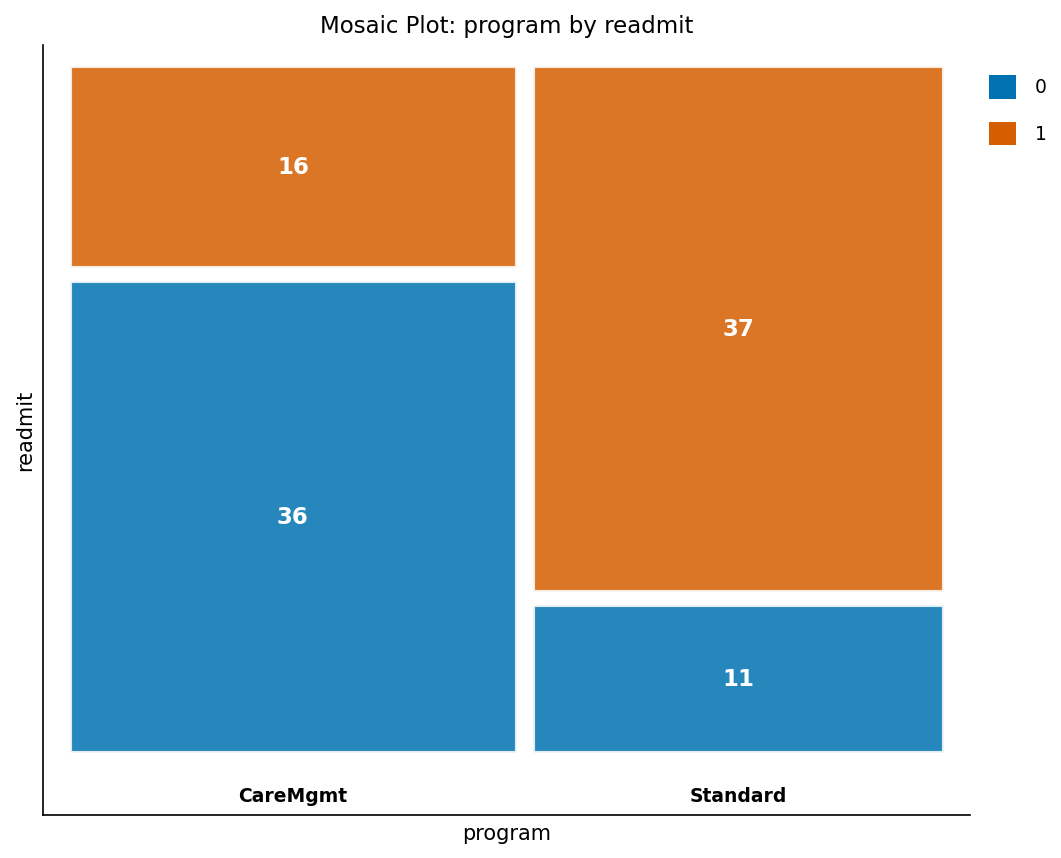

In [2]:
PROCEDIMENTO FREQUÊNCIAS DADOS=readmit;
   TABLES program*readmit / nocol nopercent;
   RÓTULO program = 'Programa'
         readmit = 'Readmissão';
EXECUTAR;

PROCEDIMENTO MÉDIAS DADOS=readmit n mean std MIN MAX;
   VARIÁVEL AGE comorbid visit readmit;
   RÓTULO AGE      = 'Idade'
         comorbid = 'Comorbidades'
         visit    = 'Consulta'
         readmit  = 'Readmissão';
EXECUTAR;


## Passo 3 — GEE logístico marginal (correlação de trabalho permutável)

A instrução `REPEATED SUBJECT=patient` declara que as observações que compartilham um `patient` são correlacionadas. `CORR=EXCH` assume que todo par de consultas dentro de um paciente tem a mesma correlação — um padrão sensato para medidas repetidas sem uma ordenação temporal forte. `CORRW` reporta o parâmetro de correlação de trabalho estimado. A instrução `CLASS` insere `program` e `sex` como efeitos categóricos; o procedimento usa `CareMgmt` como referência do fator, então o coeficiente `factor(program)Standard` reportado é a mudança em log-odds para o **cuidado padrão em relação à Gestão de Cuidados**.

O PROC GEE reporta **ambos** os erros padrão empírico (sandwich) e baseado no modelo; os erros empíricos são os que devem ser confiados, pois permanecem válidos mesmo que a correlação de trabalho esteja mal especificada.

In [3]:
PROCEDIMENTO gee DADOS=readmit;
   CLASSE program(REF="Standard") sex;
   MODELO readmit = program sex age_c comorbid visit
                 / DIST=bin LINK=logit;
   REPEATED SUBJECT=patient / CORR=exch CORRW;
   RÓTULO program  = 'Programa'
         sex      = 'Sexo'
         age_c    = 'Idade Centralizada'
         comorbid = 'Comorbidades'
         visit    = 'Consulta'
         readmit  = 'Readmissão';
EXECUTAR;


                                                   The GEE Procedure                                                    

Model formula: readmit ~ factor(program) + factor(sex) + age_c + comorbid + visit
Dependent Variable: READMIT Readmissão
Distribution: binomial
Link Function: logit
Working Correlation Structure: exchangeable
Correlation Type: Compound Symmetry
Number of Observations Read: 100
Number of Clusters: 25
QIC = 111.768066
QICu = 120.784355

Analysis Of GEE Parameter Estimates
Empirical Standard Error Estimates
Parameter                            Estimate      Std Err          Z   Pr > |Z|
Intercept                           -1.572142     0.781673    -2.0113     0.0443
factor(program)Standard              2.306431     0.466895     4.9399     0.0000
factor(sex)Male                      0.688293     0.617224     1.1151     0.2648
Idade Centralizada                   0.763003     0.464270     1.6434     0.1003
Comorbidades                         0.273238     0.210294     1.


NOTE: PROC GEE data=readmit dependent=Some("readmit") dist=Some(Binomial) corr=Some(Exchangeable)

NOTE: PROC GEE wrapper=python


## Passo 4 — Efeito do programa como razão de chances

Os coeficientes do modelo estão na escala logit. Para comunicar o efeito do programa às partes interessadas clínicas, queremos uma **razão de chances (odds ratio)**. Tomamos a estimativa empírica `factor(program)Standard` (**2.306431**) e seu erro padrão empírico (**0.466895**) do ajuste permutável acima e os exponenciamos numa breve etapa DATA: `exp(beta)` é a razão de chances de padrão versus Gestão de Cuidados, e a razão de chances protetora de Gestão de Cuidados versus Padrão é seu recíproco. Um intervalo de confiança de Wald de 95% vem de `exp(beta +/- 1.96 * SE)`. Isso transforma o coeficiente de regressão na razão de chances marginal que uma operadora de saúde ou equipe de qualidade reporta.

In [4]:
DADOS program_or;
   /* Estimativa empírica (sandwich) para Padrão vs Gestão de Cuidados a partir do
      ajuste GEE permutável (exchangeable) do Passo 3 (CareMgmt é a referência do fator).
      NOTA: a variável de erro padrão é chamada std_err (não "se") porque "se" e o
      surface-form portugues do token IF -- usa-lo como identificador quebraria o
      parser depois da traducao de palavras-chave. */
   beta    = 2.306431;
   std_err = 0.466895;
   z       = 1.959964;   /* percentil 97.5 da normal padrão */

   /* Cuidado padrão em relação à Gestão de Cuidados */
   or_standard_vs_care = EXP(beta);
   lcl_standard        = EXP(beta - z*std_err);
   ucl_standard        = EXP(beta + z*std_err);

   /* Efeito protetor da Gestão de Cuidados = contraste recíproco */
   or_care_vs_standard = EXP(-beta);
   lcl_care            = EXP(-beta - z*std_err);
   ucl_care            = EXP(-beta + z*std_err);

   FORMATO or_standard_vs_care lcl_standard ucl_standard
          or_care_vs_standard lcl_care ucl_care 8.3;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=program_or noobs RÓTULO;
   VARIÁVEL or_standard_vs_care lcl_standard ucl_standard
       or_care_vs_standard lcl_care ucl_care;
   RÓTULO or_standard_vs_care = 'RC Padrao vs Cuidados'
         lcl_standard        = 'LC Inf Padrao'
         ucl_standard        = 'LC Sup Padrao'
         or_care_vs_standard = 'RC Cuidados vs Padrao'
         lcl_care            = 'LC Inf Cuidados'
         ucl_care            = 'LC Sup Cuidados';
EXECUTAR;



RC Padrao vs Cuidados  LC Inf Padrao  LC Sup Padrao  RC Cuidados vs Padrao  LC Inf Cuidados  LC Sup Cuidados
---------------------  -------------  -------------  ---------------------  ---------------  ---------------
               10.039          4.020         25.066                  0.100            0.040            0.249




NOTE: DATA program_or


NOTE: Wrote program_or (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=program_or

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


## Passo 5 — Sensibilidade à estrutura de correlação (AR(1))

Como as consultas são ordenadas no tempo, a correlação entre consultas pode decair com a separação temporal. Reajustamos com uma correlação de trabalho **autorregressiva de primeira ordem**, `CORR=AR(1)`. Os coeficientes do GEE devem ser estáveis entre escolhas razoáveis de correlação; grandes mudanças sinalizariam uma sensibilidade que mereceria investigação. Comparar o critério de ajuste QIC entre as estruturas ajuda a escolher a melhor correlação de trabalho.

In [5]:
PROCEDIMENTO gee DADOS=readmit;
   CLASSE program(REF="Standard") sex;
   MODELO readmit = program sex age_c comorbid visit
                 / DIST=bin LINK=logit;
   REPEATED SUBJECT=patient / CORR=ar(1) CORRW;
   RÓTULO program  = 'Programa'
         sex      = 'Sexo'
         age_c    = 'Idade Centralizada'
         comorbid = 'Comorbidades'
         visit    = 'Consulta'
         readmit  = 'Readmissão';
EXECUTAR;


                                                   The GEE Procedure                                                    

Model formula: readmit ~ factor(program) + factor(sex) + age_c + comorbid + visit
Dependent Variable: READMIT Readmissão
Distribution: binomial
Link Function: logit
Working Correlation Structure: ar1
Correlation Type: First-Order Autoregressive
Number of Observations Read: 100
Number of Clusters: 25
QIC = 123.944817
QICu = 120.792514

Analysis Of GEE Parameter Estimates
Empirical Standard Error Estimates
Parameter                            Estimate      Std Err          Z   Pr > |Z|
Intercept                           -1.585344     0.777886    -2.0380     0.0415
factor(program)Standard              2.314720     0.466627     4.9605     0.0000
factor(sex)Male                      0.714028     0.613258     1.1643     0.2443
Idade Centralizada                   0.795159     0.464005     1.7137     0.0866
Comorbidades                         0.266728     0.208996     1.


NOTE: PROC GEE data=readmit dependent=Some("readmit") dist=Some(Binomial) corr=Some(Ar1)

NOTE: PROC GEE wrapper=r


## Interpretando os resultados

- **A correlação intra-paciente é positiva.** O parâmetro de correlação de trabalho permutável é **alpha = 0.058** (AR(1): **0.095**), confirmando que os desfechos repetidos de readmissão no mesmo paciente se movem juntos. Ignorar isso (regressão logística comum) subestimaria os erros padrão e superestimaria a significância.
- **Erro padrão empírico vs. baseado no modelo.** O PROC GEE reporta ambos; a inferência aqui se apoia nos erros padrão **empíricos (sandwich)**, que permanecem válidos mesmo que a correlação de trabalho esteja mal especificada. Para o efeito do programa, o erro padrão empírico é **0.467** contra um baseado no modelo de **0.566**.
- **O efeito do programa.** O coeficiente `factor(program)Standard` é **+2.306** (Z = 4.94, p < 0.0001): os pacientes em cuidado padrão têm chances de readmissão em 30 dias, com média populacional, substancialmente mais altas do que os pacientes em Gestão de Cuidados. O Passo 4 traduz isso numa **razão de chances de Gestão de Cuidados versus Padrão de 0.10 (IC de Wald de 95% de 0.040 a 0.249)** — um grande efeito protetor cujo intervalo exclui 1, portanto estatisticamente distinguível de nenhum efeito. A tabulação cruzada bruta concorda: **31% das consultas de pacientes em Gestão de Cuidados terminaram em readmissão (16/52) contra 77% no cuidado padrão (37/48)**.
- **Outros fatores.** A idade (coeficiente +0.76) e a contagem de comorbidades (+0.27) aumentam as chances de readmissão, enquanto o risco cai levemente ao longo das consultas (-0.07) — consistente com o mecanismo gerador dos dados, embora apenas o efeito do programa seja individualmente significativo neste tamanho de amostra.
- **Escolha da estrutura.** Os ajustes permutável e AR(1) dão coeficientes de programa quase idênticos (**+2.306** vs **+2.315**), portanto as conclusões sobre o efeito do programa não são um artefato da correlação assumida. A estrutura permutável tem o **QIC** mais baixo (111.77 vs 123.94), sendo portanto a correlação de trabalho de melhor ajuste aqui.

**Conclusão:** o PROC GEE fornece uma estimativa defensável, com média populacional, do efeito de um programa de cuidado sobre um desfecho binário correlacionado — exatamente a interpretação marginal que uma operadora de saúde ou equipe de melhoria de qualidade precisa, com erros padrão que respeitam o desenho de medidas repetidas.